<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Exercise.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

# Exercise: Classification
© ALX

In this exercise, we will review and assess our understanding of the core concepts of classifier model selection.

## Learning objectives

By the end of this exercise, you should be able to:
* Build and evaluate multiple types of classification models.

## Introduction

Analysing hate speech and offensive language in tweets

Our dataset consists of roughly 5,600 tweets containing instances of hate speech and offensive language. These tweets have been curated to provide a focused dataset for building sentiment analysis and toxicity detection models. Each tweet reflects varying degrees of negativity, from casual derogatory remarks to explicit expressions of prejudice and intolerance.

By examining this dataset, we aim to understand the prevalence and patterns of hate speech and offensive language in online discourse. Through data analysis, we seek insights into the factors driving such language, as well as its impact on digital communities. Ultimately, our goal is to develop tools and strategies for mitigating the spread of harmful language online and fostering a more inclusive and respectful online environment.

In [97]:
import pandas as pd
tweets_df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/classification_sprint/toxicity_tweets_cleaned.csv', index_col=0)
tweets_df

,Tweet,Toxicity
43039,i will beat a bitch ass tf,1
36956,thomasnye1 my momma saw how the girls danced a...,1
8373,user user dont forget his other incantation i...,0
27287,isnt it sad how i keep thinking youll change ...,0
56311,please tell this bitch im subbin her ik one of...,1
...,...,...
6429,animaladvocate melodylgattenby zoo says this ...,0
12737,alice doggy my petstagram instapets pet pets d...,0
12503,h a p p y w i n e p a r t y momentoafouna...,0
53172,stupid teabagger restaurant making customers p...,1


## Exercises

We are tasked with building multiple classifier models to predict whether a given tweet contains hate speech or offensive language. Our dataset consists of roughly 5,600 tweets, each accompanied by a label indicating whether it expresses toxicity.

The objective is to develop robust machine learning models capable of accurately classifying tweets as toxic or non-toxic based on their content. 

### Exercise 1

Before we can build our models, we need to first preprocess the text data. Preprocessing involves converting the text into a format that can be easily understood by the algorithms. Use `CountVectorizer` to transform the text data into a matrix where each row represents a tweet and each column represents a unique word in the vocabulary. 

Split the dataset into training and testing sets using a `80-20 split`.

In [98]:
# detect character-spaced words
def fix_spaced_words(text):
    return re.sub(
        r'\b(?:[a-zA-Z]\s+){2,}[a-zA-Z]\b',
        lambda m: m.group(0).replace(" ", ""),
        str(text)
    )

tweets_df['Tweet'] = tweets_df['Tweet'].apply(fix_spaced_words)

In [99]:
# word-segmentation
import wordninja

tweets_df['Tweet'] = tweets_df['Tweet'].apply(
    lambda x: ' '.join(wordninja.split(str(x)))
)

In [100]:
# Convert the Tweet to lowercase
tweets_df['Tweet'] = tweets_df['Tweet'].str.lower()

In [101]:
# Removing punctuation and special characters
tweets_df['Tweet'] = tweets_df['Tweet'].str.replace(r'[^\w\s]', '', regex=True)

In [102]:
# Remove Numeric characters
tweets_df['Tweet'] = tweets_df['Tweet'].str.replace(r'\d+', '', regex=True)

In [103]:
# Removing Special 
import re

tweets_df['Tweet'] = tweets_df['Tweet'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

In [104]:
# Remove HTML links
from bs4 import BeautifulSoup

tweets_df['Tweet'] = tweets_df['Tweet'].apply(
    lambda x: BeautifulSoup(x, 'html.parser').get_text()
)

In [105]:
# Remove URLS
tweets_df['Tweet'] = tweets_df['Tweet'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', x)
)

In [106]:
# Remove @mentions
tweets_df['Tweet'] = tweets_df['Tweet'].str.replace(r'@\w+', '', regex=True)

In [107]:
# Remove hashtags
# tweets_df['Tweet'] = tweets_df['Tweet'].str.replace('#', '', regex=False)

In [108]:
# Remove Emojis
# tweets_df['Tweet'] = tweets_df['Tweet'].apply(
#     lambda x: x.encode('ascii', 'ignore').decode('ascii')
# )

In [109]:
# Remove extra whitespace
tweets_df['Tweet'] = tweets_df['Tweet'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

In [110]:
# Remove stopwords
from nltk.corpus import stopwords
import nltk

stop_words = set(stopwords.words('english'))
tweets_df['Tweet'] = tweets_df['Tweet'].apply(
    lambda x: ' '.join(
        [word for word in x.split() 
         if word not in stop_words])
)

In [111]:
# Tokenization
from nltk.tokenize import word_tokenize

tweets_df['Tokenized_Tweet'] = tweets_df['Tweet'].apply(word_tokenize)

In [112]:
# Lemmatization
# from nltk.stem import WordNetLemmatizer

# lemmatizer = WordNetLemmatizer()

# tweets_df['Tweet'] = tweets_df['Tokenized_Tweet'].apply(
#     lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x])
# )

In [113]:
tweets_df

,Tweet,Toxicity,Tokenized_Tweet
43039,beat bitch f,1,"[beat, bitch, f]"
36956,thomas nye momma saw girls danced like grandma...,1,"[thomas, nye, momma, saw, girls, danced, like,..."
8373,user user dont forget incantation ive always w...,0,"[user, user, dont, forget, incantation, ive, a..."
27287,isnt sad keep thinking change mind love back f...,0,"[isnt, sad, keep, thinking, change, mind, love..."
56311,please tell bitch im sub bin ik one fag gs fuc...,1,"[please, tell, bitch, im, sub, bin, ik, one, f..."
...,...,...,...
6429,animal advocate melody lg ten zoo says lion li...,0,"[animal, advocate, melody, lg, ten, zoo, says,..."
12737,alice doggy pets tag ram insta pets pet pets d...,0,"[alice, doggy, pets, tag, ram, insta, pets, pe..."
12503,happy wine party moment oaf una wine vino fo u...,0,"[happy, wine, party, moment, oaf, una, wine, v..."
53172,stupid teabag ger restaurant making customers ...,1,"[stupid, teabag, ger, restaurant, making, cust..."


In [114]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer


count_vectorizer = CountVectorizer()

X = count_vectorizer.fit_transform(tweets_df['Tweet'])
print(count_vectorizer.get_feature_names_out())
print(X.toarray())

['aaa' 'aaaa' 'aaaaaa' ... 'zy' 'zz' 'zzz']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [115]:
y = tweets_df['Toxicity']

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Exercise 2

Now we can build classifier models using the training data and assess their performance on the testing data.

Implement the following models: `Logistic Regression`, `Decision Tree`, `Support Vector Classification`, and `Nearest Neighbors`. Evaluate each model's performance using the following evaluation metrics: `accuracy`, `precision`, `recall`, and `F1 score`. Note: Running these models might take a few minutes, depending on the complexity chosen. 

In addition to this, calculate the confusion matrix for each of our models. 

What do these results tell us about our models?

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [118]:
names = ['Logistic Regression', 'Nearest Neighbors', 
         'Linear SVM', 'RBF SVM',          
         'Decision Tree', 'Random Forest',  'AdaBoost']

In [119]:
# Define the classifiers with their respective hyperparameters
classifiers = [
    LogisticRegression(), 
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(gamma=2, C=1),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),    
    AdaBoostClassifier()
]

In [126]:
import warnings
import time
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score
warnings.filterwarnings('ignore')

results = []
models = {}
confusion_matrices = {}
class_reports = {}

for name, clf in zip(names, classifiers):
    print(f"Training {name} model...")

    start_time = time.perf_counter()
    clf.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time
    print("...Predicting...")

    y_pred = clf.predict(X_test)
    y_pred_test = clf.predict(X_test)
    y_pred_train = clf.predict(X_train)

    print("...Evaluating...")
    train_accuracy = clf.score(X_train, y_train)
    train_precision = precision_score(y_train, y_pred_train, average='weighted')
    train_recall = recall_score(y_train, y_pred_train, average='weighted')
    train_f1 = 2 * (train_precision * train_recall) / (train_precision + train_recall)

    test_accuracy = clf.score(X_test, y_test)
    test_precision = precision_score(y_test, y_pred_test, average='weighted')
    test_recall = recall_score(y_test, y_pred_test, average='weighted')
    test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

    results.append({
        'Model': name,
        'Train_Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Train_Precision': train_precision,
        'Test_Precision': test_precision,
        'Train_Recall': train_recall,
        'Test_Recall': test_recall,
        'Train_F1': train_f1,
        'Test_F1': test_f1,
        'Training_Time(s)': training_time
    })

    models[name] = clf
    confusion_matrices[name] = confusion_matrix(y_test, y_pred_test)
    class_reports[name] = classification_report(y_test, y_pred_test)

# Create a DataFrame to display the results
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
results_df = results_df.sort_values(by='Test Accuracy', ascending=False)
results_df

Training Logistic Regression model...
...Predicting...
...Evaluating...
Training Nearest Neighbors model...
...Predicting...
...Evaluating...
Training Linear SVM model...
...Predicting...
...Evaluating...
Training RBF SVM model...
...Predicting...
...Evaluating...
Training Decision Tree model...
...Predicting...
...Evaluating...
Training Random Forest model...
...Predicting...
...Evaluating...
Training AdaBoost model...
...Predicting...
...Evaluating...


,Train_Accuracy,Test Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Training_Time(s)
Model,,,,,,,,,
Logistic Regression,0.992069,0.921586,0.992113,0.923558,0.992069,0.921586,0.992091,0.922571,0.062410
Linear SVM,0.903503,0.882819,0.914852,0.898403,0.903503,0.882819,0.909142,0.890543,0.749775
AdaBoost,0.860983,0.864317,0.873936,0.880347,0.860983,0.864317,0.867411,0.872258,2.231408
Nearest Neighbors,0.916061,0.848458,0.920135,0.855054,0.916061,0.848458,0.918093,0.851743,0.000622
Decision Tree,0.849306,0.844053,0.870166,0.866486,0.849306,0.844053,0.859610,0.855122,0.054130
RBF SVM,1.000000,0.582379,1.000000,0.757248,1.000000,0.582379,1.000000,0.658400,1.638386
Random Forest,0.573254,0.579736,0.755406,0.336093,0.573254,0.579736,0.651844,0.425506,0.012215


In [129]:
for name, matrix in confusion_matrices.items():
    print(f"Confusion Matrix for {name}:\n{matrix}\n")

Confusion Matrix for Logistic Regression:
[[637  21]
 [ 68 409]]

Confusion Matrix for Nearest Neighbors:
[[620  38]
 [134 343]]

Confusion Matrix for Linear SVM:
[[652   6]
 [127 350]]

Confusion Matrix for RBF SVM:
[[658   0]
 [474   3]]

Confusion Matrix for Decision Tree:
[[646  12]
 [165 312]]

Confusion Matrix for Random Forest:
[[658   0]
 [477   0]]

Confusion Matrix for AdaBoost:
[[645  13]
 [141 336]]



In [130]:
for name, class_report in class_reports.items():
    print(f"Classification Report for {name}:\n{class_report}\n")

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       658
           1       0.95      0.86      0.90       477

    accuracy                           0.92      1135
   macro avg       0.93      0.91      0.92      1135
weighted avg       0.92      0.92      0.92      1135


Classification Report for Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       658
           1       0.90      0.72      0.80       477

    accuracy                           0.85      1135
   macro avg       0.86      0.83      0.84      1135
weighted avg       0.86      0.85      0.85      1135


Classification Report for Linear SVM:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       658
           1       0.98      0.73      0.84       477

    accuracy                           0.88      1

### Exercise 3
In addition to the performance evaluation based on metrics and confusion matrices, cross-validation scores provide further insights into the robustness and generalisation capabilities of classifier models. 

After evaluating the performance of our classifier models, we want to determine the best model based on their cross-validation scores. 

Perform 5-fold cross-validation for each classifier model using the training data and print the `mean cross-validation score`.

**Note**: This code should take a few minutes to run

In [131]:
from sklearn.model_selection import cross_val_score

cv = []


for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    cv.append({
        'Model': name,
        'Cross_Val_Score_Mean': scores.mean(),
        'Cross_Val_Score_Std': scores.std()
    })

cv_df = pd.DataFrame(cv, columns=['Model', 'Cross_Val_Score_Mean', 'Cross_Val_Score_Std'])
cv_df = cv_df.set_index('Model')

In [132]:
cv_df = cv_df.sort_values(by='Cross_Val_Score_Mean', ascending=False)
cv_df

,Cross_Val_Score_Mean,Cross_Val_Score_Std
Model,,
Logistic Regression,0.917869,0.008276
Linear SVM,0.887203,0.010869
AdaBoost,0.860943,0.007203
Nearest Neighbors,0.853718,0.011859
Decision Tree,0.845785,0.008624
RBF SVM,0.578957,0.003025
Random Forest,0.574374,0.000150


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample text data
data = ["Machine learning is fascinating.", "Natural language processing and machine learning are closely linked."]

# Initialise the CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the data
X = vectorizer.fit_transform(data)

# Get the feature names
feature_names = vectorizer.get_feature_names_out()
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 13 stored elements and shape (2, 11)>

In [135]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Initialise the Logistic Regression model
logreg = LogisticRegression(solver='liblinear')

# Train the model
logreg.fit(X_train, y_train)

# Predict the test set results
y_pred = logreg.predict(X_test)
# insert code here
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.958041958041958


In [138]:
from sklearn.metrics import confusion_matrix
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Generate synthetic binary classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Initialise and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

# Predict the test set results
y_pred = rf_classifier.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# insert code here
print("Confusion Matrix:\n", cm)

true_positive = cm[1, 1]
true_negative = cm[0, 0]
print(f"True Positives: {true_positive}")
print(f"True Negatives: {true_negative}")

Confusion Matrix:
 [[107   8]
 [ 22 113]]
True Positives: 113
True Negatives: 107


In [139]:
from sklearn.datasets import load_digits
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import numpy as np

# Load a dataset
digits = load_digits()
X = digits.data
y = digits.target

# Initialise an SVC (Support Vector Classifier) with a linear kernel
svm = SVC(kernel='linear')

# Define parameter range for C (regularisation parameter)
param_grid = {'C': np.logspace(-3, 3, 7)}

# Setup the grid search with cross-validation
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')

# Fit grid search
grid_search.fit(X, y)
# insert code here
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters: {'C': np.float64(0.001)}
Best cross-validation score: 0.951047663262148


In [140]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score

# Generate a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Initialise KNN and Naive Bayes classifiers
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()

# Train both classifiers on the training data
knn.fit(X_train, y_train)
nb.fit(X_train, y_train)

# Predict test set results for both classifiers
y_pred_knn = knn.predict(X_test)
y_pred_nb = nb.predict(X_test)

# Calculate F1 scores for both classifiers
f1_knn = f1_score(y_test, y_pred_knn)
f1_nb = f1_score(y_test, y_pred_nb)

# Compare F1 scores
def print_best_classifier(f1_knn, f1_nb):
    if f1_knn > f1_nb:
        print(f"KNN has the higher F1 score of {f1_knn}")
    elif f1_knn < f1_nb:
        print(f"Naive Bayes has the higher F1 score of {f1_nb}")
    else:
        print(f"Both classifiers have the same F1 score of {f1_knn}")
print_best_classifier(f1_knn, f1_nb)

KNN has the higher F1 score of 0.8064516129032258


In [141]:
def evaluate_classifiers(f1_knn, f1_nb):
    if f1_knn > f1_nb:
        print(f"Naive Bayes has the higher F1 score of {f1_nb}")
    elif f1_nb > f1_knn:
        print(f"KNN has the higher F1 score of {f1_knn}")
    else:
        print(f"Both classifiers have the same F1 score of {f1_nb}")
evaluate_classifiers(f1_knn, f1_nb)

Naive Bayes has the higher F1 score of 0.7901234567901234


In [142]:
def compare_f1_scores(f1_knn, f1_nb):
    if f1_knn >= f1_nb:
        print(f"KNN has the higher F1 score of {f1_knn}")
    else:
        print(f"Naive Bayes has the higher F1 score of {f1_nb}")
compare_f1_scores(f1_knn, f1_nb)

KNN has the higher F1 score of 0.8064516129032258


In [143]:
def best_f1_score(f1_knn, f1_nb):
    print(f"KNN: {f1_knn}, Naive Bayes: {f1_nb}")
best_f1_score(f1_knn, f1_nb)

KNN: 0.8064516129032258, Naive Bayes: 0.7901234567901234


In [144]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# Generate a two-moon dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialise the MLPClassifier with one hidden layer with 10 neurons
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)


mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
misclassified = np.where(y_test != y_pred, 1, 0)
print(misclassified.sum())

7


In [145]:
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
print(np.sum(y_test != y_pred))

7


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Setup a basic decision tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Define a parameter grid over which to optimise the decision tree
param_grid = {
 'max_depth': [None, 10, 20, 30],
 'min_samples_split': [2, 10, 20]
}

param_grid['max_features'] = [1, 2, 3, 4]

# Setup the GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score}")

Best parameters: {'max_depth': None, 'max_features': 2, 'min_samples_split': 20}
Best cross-validation score: 0.9371541501976285


In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Generate synthetic data for binary classification
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train a RandomForest classifier
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

# Predict probabilities for the test set
y_scores = classifier.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.3 , 0.31, 0.33, 0.37, 0.38, 0.41,
       0.42, 0.43, 0.44, 0.46, 0.47, 0.49, 0.5 , 0.52, 0.54, 0.55, 0.57,
       0.58, 0.59, 0.64, 0.65, 0.66, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74,
       0.75, 0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85,
       0.86, 0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96,
       0.97, 0.98, 0.99, 1.  ])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Initialise the Logistic Regression model
lr = LogisticRegression()

# [Your Code Here] - Apply feature scaling to the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# [Your Code Here] - Fit the model on the scaled training data
lr.fit(X_train_scaled, y_train)

# [Your Code Here] - Apply the same scaling to the test data
X_test_scaled = scaler.transform(X_test)

In [153]:
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load a dataset of digit images
digits = load_digits()
X = digits.data
y = digits.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Initialise two SVM classifiers, one with a linear kernel and another with an RBF kernel
svm_linear = SVC(kernel='linear')
svm_rbf = SVC(kernel='rbf')

# [Your Code Here] - Train both classifiers on the training data
svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

# [Your Code Here] - Predict the test set results with both classifiers
y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

# [Your Code Here] - Calculate and print the accuracy scores for both classifiers
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Accuracy (Linear SVM): {accuracy_linear}")
print(f"Accuracy (RBF SVM): {accuracy_rbf}")

Accuracy (Linear SVM): 0.9822222222222222
Accuracy (RBF SVM): 0.9866666666666667


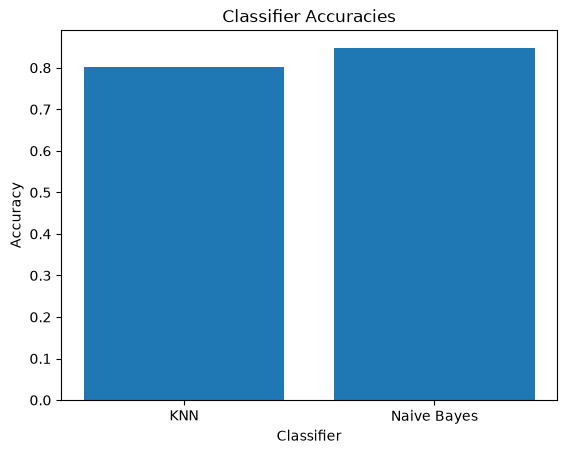

In [154]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
data = fetch_20newsgroups(subset='all')
X = data.data
y = data.target

# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorise text data
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Initialise classifiers
knn = KNeighborsClassifier()
nb = MultinomialNB()

# Train classifiers
knn.fit(X_train_tfidf, y_train)
nb.fit(X_train_tfidf, y_train)

# Predict and calculate accuracy
knn_accuracy = accuracy_score(y_test, knn.predict(X_test_tfidf))
nb_accuracy = accuracy_score(y_test, nb.predict(X_test_tfidf))

# [Your code here] - Plot the accuracies in a bar chart
plt.bar(['KNN', 'Naive Bayes'], [knn_accuracy, nb_accuracy])
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies')
plt.show()

In [156]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Generate synthetic binary classification data
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train a Random Forest classifier
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

# Predict the test set results
y_pred = classifier.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
# [Your code here] - Extract and print True Positives and False Positives
true_positives = cm[1, 1]
false_positives = cm[0, 1]

print(f"True Positives: {true_positives}")
print(f"False Positives: {false_positives}")

Confusion Matrix:
 [[107   8]
 [ 22 113]]
True Positives: 113
False Positives: 8


## Solutions

### Exercise 1

In [122]:

# from sklearn.feature_extraction.text import CountVectorizer

# # Create CountVectorizer object
# vectorizer = CountVectorizer()

# # Fit the vectorizer on the tweet text data
# X = vectorizer.fit_transform(tweets_df['Tweet'])

# # Convert the sparse matrix to an array
# X_array = X.toarray()

# from sklearn.model_selection import train_test_split
# # Split the dataset into training and testing sets
# # Split the data into features (X) and target labels (y)
# X_train, X_test, y_train, y_test = train_test_split(X_array, tweets_df['Toxicity'], test_size=0.2, random_state=42)

### Exercise 2

In [123]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# from sklearn.metrics import confusion_matrix


# # Initialize the classifiers
# classifiers = {
#     "Logistic Regression": LogisticRegression(),
#     "Decision Tree": DecisionTreeClassifier(),
#     "Support Vector Classification": SVC(),
#     "Nearest Neighbors": KNeighborsClassifier()
# }

# # Train and evaluate each classifier
# conf_matrices = {}
# results = {}
# for name, clf in classifiers.items():
#     clf.fit(X_train, y_train)
#     y_pred = clf.predict(X_test)
#     # Calculate evaluation metrics
#     accuracy = accuracy_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred)
#     recall = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)
#     results[name] = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1}
#     # Calculate confusion matrix
#     conf_matrix = confusion_matrix(y_test, y_pred)
#     conf_matrices[name] = conf_matrix

# # Display results
# for name, metrics in results.items():
#     print(f"Metrics for {name}:")
#     print(metrics)
#     print()

# # Display confusion matrices
# for name, conf_matrix in conf_matrices.items():
#     print(f"Confusion Matrix for {name}:")
#     print(conf_matrix)
#     print()



Using Python (3.10.14), our results seem to be best for the Decision Tree model in terms of its F1 score, boasting high accuracy, precision, recall, comparing favourably to the other classifiers. The Logistic Regression model follows closely, with its ability to correctly classify a significant proportion of samples, coupled with balanced precision and recall metrics, also showing its robustness in handling toxic and non-toxic instances. Support Vector Classification (SVC), while exhibiting high precision, falters in recall, leading to an imbalance between false negatives and false positives. Nearest Neighbors (KNN), with the lowest accuracy and F1 score, struggles to strike a balance between precision and recall, resulting in suboptimal predictive performance.

It is however important to note a few things. Firstly, the skeleton for models provided here are only the start of the process of finding a suitable model. In reality, we cannot say with full certainty that the KNN model is less suitable than another if we've not attempted to find the optimal combination of hyperparameters (by not specifying the number of neighbours for instance, the default used here was 5). Secondly, if two models seem to perform similarly in terms of precision, accuracy and recall, it might be worth deciding whether False Positives are a **more wanted** phenomena than False Negatives. In the medical world, this might be prefereable. These findings underscore the importance of meticulously evaluating various classifiers and choosing the most suitable model based on specific task requirements and performance metrics.

### Exercise 3

In [124]:
# from sklearn.model_selection import cross_val_score
# # Dictionary to store cross-validation scores
# cv_scores = {}

# # Perform cross-validation for each classifier
# for name, clf in classifiers.items():
#     # Perform 5-fold cross-validation and store the scores
#     cv_scores[name] = cross_val_score(clf, X_train, y_train, cv=5).mean()

# # Display cross-validation scores
# for name, scores in cv_scores.items():
#     print(f"Cross-validation scores for {name}:")
#     print(scores)
#     print()

`Logistic Regression` maintains its superiority with the highest cross-validation score of 0.904, affirming its consistency in performance across multiple data splits. `Decision Tree` follows closely, demonstrating stable performance with a cross-validation score of 0.895. However, `Support Vector Classification (SVC)` and `Nearest Neighbors` continue to lag behind, with scores of 0.889 and 0.785, respectively. While `SVC` exhibits reasonable cross-validation performance, `Nearest Neighbors` struggles to generalise well to unseen data, indicating potential overfitting or model complexity issues. These cross-validation results reinforce the findings from the earlier performance evaluation, reaffirming `Logistic Regression` as the preferred choice for predicting toxicity levels in this dataset.

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/refs/heads/master/ALX_banners/ALX_Navy.png"  style="width:100px";/>
</div>